# Chord Tension Experiment — Analysis

### A simulated experiment: 

Participants heard isolated chords and rated the **tension** they felt on a continuous 0–100 scale (visual-analogue slider).

**Dataset** (`data/chord_tension_ratings.csv`, one row per trial):

| Column | Meaning |
|---|---|
| `trial` | Trial number within a participant's session (1–35, randomised order) |
| `participant_id` | Participant code (P01–P24) |
| `chord_type` | Chord presented (Major, minor, augmented, major-seventh, dominant-seventh, diminished-seventh, half-diminished) |
| `tension_rating` | Tension rating, continuous 0 (relaxed) – 100 (very tense) |
| `dissonance` | Dissonance of the chord as presented, operationalised as spectral roughness (0–1, higher = more dissonant; grows slightly with loudness) |
| `loudness_db` | Presentation level in dB SPL (~55–85) |

The data are simulated by `generate_data.py` — tension increases with dissonance and loudness, plus participant-level and trial-level noise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# --- shared plot styling -----------------------------------------------------
BLUE, ORANGE = "#2a78d6", "#eb6834"          # series colours
SEQ_BLUES = ["#86b6ef", "#2a78d6", "#0d366b"]  # light -> dark, for ordered levels
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 11,
})

## 1. Load and inspect the data

This table reports the results of the experiment: each row corresponds to a single response (trial) from one participant.

In [3]:
df = pd.read_csv("chord-tension-experiment/data/chord_tension_ratings.csv")
print(f"{len(df)} trials, {df['participant_id'].nunique()} participants, "
      f"{df['chord_type'].nunique()} chord types")
df.head(10)

840 trials, 24 participants, 7 chord types


,trial,participant_id,chord_type,tension_rating,dissonance,loudness_db
0,1,P01,major-seventh,30.4,0.163,60.7
1,2,P01,augmented,73.9,0.507,71.5
2,3,P01,dominant-seventh,12.2,0.308,66.2
3,4,P01,Major,15.2,0.080,69.8
4,5,P01,dominant-seventh,44.0,0.337,75.3
5,6,P01,dominant-seventh,22.7,0.312,67.5
6,7,P01,minor,22.9,0.152,78.8
7,8,P01,major-seventh,1.8,0.171,64.8
8,9,P01,half-diminished,43.7,0.516,84.7
9,10,P01,diminished-seventh,22.4,0.526,65.7


In [4]:
df.describe().round(2)

,trial,tension_rating,dissonance,loudness_db
count,840.00,840.00,840.00,840.00
mean,18.00,31.54,0.32,70.07
std,10.11,21.80,0.18,8.73
min,1.00,0.00,0.07,55.10
25%,9.00,13.78,0.15,62.20
50%,18.00,30.05,0.32,70.25
75%,27.00,47.12,0.48,77.50
max,35.00,89.30,0.63,84.90


Mean tension per chord type, next to each chord's average presented dissonance — tension should track dissonance:

In [8]:
(df.groupby("chord_type")
   .agg(n_trials=("tension_rating", "size"),
        mean_tension=("tension_rating", "mean"),
        mean_dissonance=("dissonance", "mean"))
   .sort_values("mean_tension")
   .round(2))

,n_trials,mean_tension,mean_dissonance
chord_type,,,
Major,120,13.59,0.08
minor,120,15.91,0.14
major-seventh,120,18.76,0.18
dominant-seventh,120,31.09,0.32
half-diminished,120,41.96,0.45
augmented,120,47.04,0.50
diminished-seventh,120,52.42,0.56


## 2. Tension by chord type — per participant (interactive)

Pick a participant from the dropdown. Small dots are single trials; orange diamonds are that participant's mean rating per chord type. Chord types are ordered left to right by their average presented dissonance.

In [ ]:
from ipywidgets import interact, Dropdown

rng = np.random.default_rng(7)

# chord types ordered by their mean presented dissonance (low -> high)
CHORD_ORDER = (df.groupby("chord_type")["dissonance"].mean()
                 .sort_values().index.tolist())
XPOS = {chord: i for i, chord in enumerate(CHORD_ORDER)}

def plot_participant(participant):
    d = df[df["participant_id"] == participant]
    fig, ax = plt.subplots(figsize=(9, 4.8))

    x = d["chord_type"].map(XPOS)
    jx = rng.normal(0, 0.06, len(d))
    ax.scatter(x + jx, d["tension_rating"],
               s=30, color=BLUE, alpha=0.5, edgecolors="none", zorder=2)

    means = d.groupby("chord_type")["tension_rating"].mean()
    ax.scatter([XPOS[c] for c in means.index], means.values,
               s=80, marker="D", color=ORANGE,
               edgecolors="white", linewidths=1.2, zorder=3)

    ax.set_xticks(range(len(CHORD_ORDER)))
    ax.set_xticklabels(CHORD_ORDER, rotation=20, ha="right")
    ax.xaxis.grid(False)
    ax.set_xlabel("Chord type (ordered by dissonance)")
    ax.set_ylabel("Tension rating (0–100)")
    ax.set_ylim(-4, 104)
    ax.set_title(f"Participant {participant}: tension by chord type",
                 color=INK, fontsize=12)
    fig.tight_layout()
    plt.show()

interact(plot_participant,
         participant=Dropdown(options=sorted(df["participant_id"].unique()),
                              description="Participant"));

interactive(children=(Dropdown(description='Participant', options=('P01', 'P02', 'P03', 'P04', 'P05', 'P06', '…

## 3. Regression: dissonance and loudness effects on tension

We hypothesize that tension depnds on some combination of dissonance and loudness:

$$\text{tension} = \beta_0 + \beta_1\,\text{dissonance} + \beta_2\,\text{loudness} + \varepsilon$$

In [11]:
def ols(y, X, names):
    "OLS with coefficient table (no statsmodels needed)."
    X = np.column_stack([np.ones(len(y)), X])
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    resid = y - X @ beta
    dof = len(y) - X.shape[1]
    sigma2 = resid @ resid / dof
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))
    tvals = beta / se
    pvals = 2 * stats.t.sf(np.abs(tvals), dof)
    r2 = 1 - (resid @ resid) / ((y - y.mean()) @ (y - y.mean()))
    table = pd.DataFrame({"coef": beta, "SE": se, "t": tvals, "p": pvals},
                         index=["intercept"] + names)
    return beta, table, r2

y = df["tension_rating"].to_numpy(dtype=float)
X = np.column_stack([df["dissonance"], (df["loudness_db"] - 70) / 10])
beta, table, r2 = ols(y, X, ["dissonance", "loudness (per +10 dB)"])

print(f"R² = {r2:.3f}   (n = {len(df)} trials)")
table.round(3)

R² = 0.678   (n = 840 trials)


,coef,SE,t,p
intercept,5.652,0.887,6.369,0.0
dissonance,81.119,2.446,33.164,0.0
loudness (per +10 dB),8.956,0.502,17.853,0.0


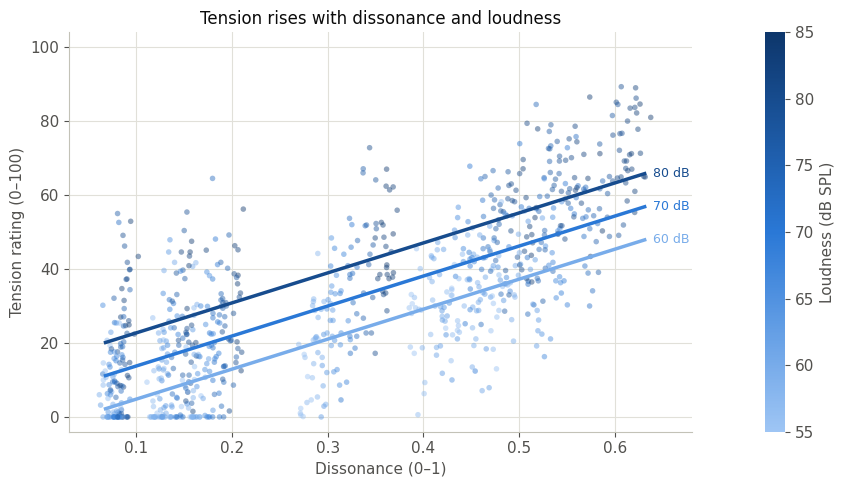

In [12]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

# one light -> dark blue ramp encodes loudness for both dots and lines
LOUD_CMAP = LinearSegmentedColormap.from_list("loudness_blues",
                                              ["#9ec5f4", "#2a78d6", "#0d366b"])
loud_norm = Normalize(vmin=55, vmax=85)

fig, ax = plt.subplots(figsize=(8.6, 5))

jx = rng.normal(0, 0.006, len(df))
ax.scatter(df["dissonance"] + jx, df["tension_rating"],
           c=df["loudness_db"], cmap=LOUD_CMAP, norm=loud_norm,
           s=16, alpha=0.45, edgecolors="none", zorder=2)

xs = np.linspace(df["dissonance"].min(), df["dissonance"].max(), 50)
for level in [60, 70, 80]:
    colour = LOUD_CMAP(loud_norm(level))
    yhat = beta[0] + beta[1] * xs + beta[2] * (level - 70) / 10
    ax.plot(xs, yhat, color=colour, linewidth=2.5, zorder=3)
    ax.annotate(f"{level} dB", (xs[-1], yhat[-1]), xytext=(6, 0),
                textcoords="offset points", va="center",
                fontsize=9, color=colour)

cbar = fig.colorbar(ScalarMappable(norm=loud_norm, cmap=LOUD_CMAP),
                    ax=ax, pad=0.10, fraction=0.05)
cbar.set_label("Loudness (dB SPL)", color=MUTED)
cbar.ax.tick_params(color=MUTED, labelcolor=MUTED)
cbar.outline.set_visible(False)

ax.set_xlabel("Dissonance (0–1)")
ax.set_ylabel("Tension rating (0–100)")
ax.set_ylim(-4, 104)
ax.set_xlim(0.03, 0.68)
ax.set_title("Tension rises with dissonance and loudness",
             color=INK, fontsize=12)
fig.tight_layout()
plt.show()

**Reading the plot.** Each dot is the response of one participant to one particular chord.

The x axis reports dissonance: chords to the right are more dissonant than chords to the left. The y axis reports the participant's tension rating for each chord. It looks like 

Dot colour encodes the loudness at which each trial was presented (light → dark blue = quiet → loud; see the colourbar). Darker dots are higher up in the tension scale: increased loudness does seem to induce higher tension. 

Each one of the three lines shows how tension varies as a function of dissonance at a fixed loudness level (60 / 70 / 80 dB). The upward slope is the effect of dissonance on tension (β₁ > 0: more dissonant chords are rated more tense); the vertical separation between the lines is the effect of loudness (β₂ > 0: louder chords are rated more tense).